In [40]:
# ==========================================
# ⚙️ ส่วนตั้งค่า (CONFIGURATION) - ปรับแก้ตรงนี้ได้เลย
# ==========================================
SYMBOL = "SNDK"       # ชื่อหุ้น (เช่น AAPL, TSLA, BTC-USD, PTT.BK)
PERIOD = "5mo"         # ย้อนหลัง: 1d, 5d, 1mo, 6mo, 1y, 2y, 5y, 10y, max
INTERVAL = "1h"       # ความละเอียด: 1m, 2m, 5m, 15m, 30m, 1h, 1d, 1wk, 1mo
PREDICTION_STEPS = 21 # จำนวนแท่งเทียนที่จะทำนายล่วงหน้า (30 วัน หรือ 30 ชั่วโมง ขึ้นอยู่กับ Interval)

In [41]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from chronos import ChronosPipeline

In [42]:
# ==========================================
# 1. โหลดโมเดล
# ==========================================
try:
    pipeline = ChronosPipeline.from_pretrained(
        "amazon/chronos-t5-large",
        device_map="cuda", 
        torch_dtype=torch.bfloat16,
    )
except Exception as e:
    print("⚠️ ไม่พบ GPU หรือ VRAM ไม่พอ เปลี่ยนไปใช้ CPU และโมเดลขนาดเล็ก...")
    pipeline = ChronosPipeline.from_pretrained(
        "amazon/chronos-t5-small",
        device_map="cpu", 
        torch_dtype=torch.float32,
    )

In [43]:
# ==========================================
# 2. ฟังก์ชันแปลง Interval เป็น Frequency (หัวใจสำคัญ)
# ==========================================
def get_pandas_freq(interval):
    """แปลง yfinance interval เป็น pandas offset string"""
    mapping = {
        "1m": "1min", "2m": "2min", "5m": "5min",
        "15m": "15min", "30m": "30min", "60m": "60min", "90m": "90min",
        "1h": "1h", 
        "1d": "D", "5d": "5D", 
        "1wk": "W", "1mo": "ME" # Pandas ใหม่ใช้ 'ME' แทน 'M' (Month End)
    }
    return mapping.get(interval, "D") # ค่า default คือรายวัน

In [44]:
# ==========================================
# 3. ดึงและเตรียมข้อมูล (Robust Data Pipeline)
# ==========================================
print(f"🔄 กำลังดึงข้อมูล {SYMBOL} (Period: {PERIOD}, Interval: {INTERVAL})...")
df = yf.download(SYMBOL, period=PERIOD, interval=INTERVAL, auto_adjust=True)

# 3.1 แก้ไข MultiIndex (สำหรับ yfinance เวอร์ชันใหม่)
if isinstance(df.columns, pd.MultiIndex):
    try:
        df = df.xs(SYMBOL, axis=1, level=1)
    except KeyError:
        pass

# 3.2 หาคอลัมน์ราคา (Close/Adj Close)
target_col = "Close"
if "Close" not in df.columns and "Adj Close" in df.columns:
    target_col = "Adj Close"

# 3.3 จัดการ Index และ Timezone (สำคัญมากเพื่อความยืดหยุ่น)
df.index = pd.to_datetime(df.index)

# ล้าง Timezone ทิ้งทันที (ทำให้เป็น Local Time ที่ไม่มีโซน) ป้องกัน Error ข้ามโซน
if df.index.tz is not None:
    df.index = df.index.tz_localize(None)

# 3.4 ตั้งชื่อ Index ให้เป็นมาตรฐานเดียวกันหมด
df.index.name = "timestamp"

# 3.5 บังคับความถี่ (Frequency) ให้ตรงกับ Interval ที่เลือก
pandas_freq = get_pandas_freq(INTERVAL)
print(f"ℹ️ กำลังจัดระเบียบข้อมูลด้วยความถี่: {pandas_freq}")

# ใช้ resample().last() ปลอดภัยกว่า asfreq() กรณีข้อมูล Intraday มาไม่ตรงวินาทีเป๊ะๆ
df = df.resample(pandas_freq).last()

# 3.6 เติมข้อมูลที่ขาดหาย (ตลาดปิด/วันหยุด)
# ถ้าเป็นข้อมูลรายนาที/ชั่วโมง (Intraday) การ ffill ข้ามคืนอาจจะไม่แม่นยำเท่าไหร่แต่จำเป็นสำหรับ Chronos
df = df.ffill() 
df = df.dropna() # ลบค่าว่างหัวท้าย

df = df.reset_index()

# เช็คว่าข้อมูลพอไหม
if len(df) < 20:
    raise ValueError(f"❌ ข้อมูลน้อยเกินไป ({len(df)} แถว) ลองเพิ่ม Period หรือลด Interval")

🔄 กำลังดึงข้อมูล SNDK (Period: 5mo, Interval: 1h)...


[*********************100%***********************]  1 of 1 completed

ℹ️ กำลังจัดระเบียบข้อมูลด้วยความถี่: 1h


In [45]:
# ==========================================
# 4. เตรียม Context และ พยากรณ์
# ==========================================
context_df = pd.DataFrame({
    "id": [SYMBOL] * len(df),
    "timestamp": df["timestamp"],
    "target": df[target_col]
})

print(f"🔮 กำลังพยากรณ์ล่วงหน้า {PREDICTION_STEPS} จุดข้อมูล ({INTERVAL})...")

forecast = pipeline.predict_df(
    context_df,
    prediction_length=PREDICTION_STEPS,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="timestamp",
    target="target"
)

🔮 กำลังพยากรณ์ล่วงหน้า 21 จุดข้อมูล (1h)...


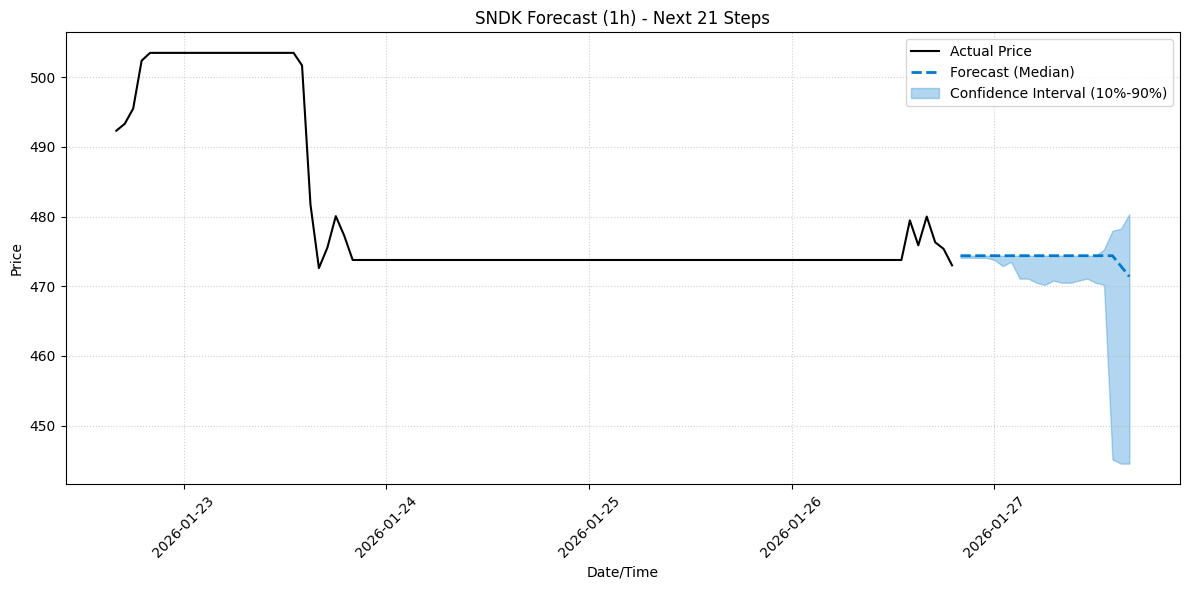


--- 📊 Analysis Result ---
Interval ที่ใช้: 1h (ทำนาย 21 steps)
ราคาล่าสุด: 473.00
ราคาคาดการณ์ปลายทาง: 471.40
แนวโน้ม: ลบ 📉 (-0.34%)


In [46]:
# ==========================================
# 5. Visualization (กราฟ)
# ==========================================
actual_past = context_df.tail(100) # ดูย้อนหลัง 100 จุด (ปรับได้)

plt.figure(figsize=(12, 6))

# พล็อตราคาจริง
plt.plot(actual_past["timestamp"], actual_past["target"], label="Actual Price", color="black", linewidth=1.5)

# พล็อตพยากรณ์
plt.plot(forecast["timestamp"], forecast["0.5"], label="Forecast (Median)", color="#007acc", linestyle="--", linewidth=2)

# พล็อตช่วงความเชื่อมั่น
plt.fill_between(
    forecast["timestamp"], 
    forecast["0.1"], 
    forecast["0.9"], 
    color="#007acc", alpha=0.3, label="Confidence Interval (10%-90%)"
)

# ตั้งชื่อกราฟให้ dynamic ตามค่าที่ตั้ง
time_unit = "Days" if "d" in INTERVAL else ("Weeks" if "wk" in INTERVAL else "Steps")
plt.title(f"{SYMBOL} Forecast ({INTERVAL}) - Next {PREDICTION_STEPS} {time_unit}")
plt.xlabel("Date/Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45) # เอียงวันที่ให้อ่านง่ายขึ้น
plt.tight_layout()
plt.show()

# สรุปผล
last_val = actual_past["target"].iloc[-1]
pred_val = forecast["0.5"].iloc[-1]
diff = ((pred_val - last_val) / last_val) * 100
print(f"\n--- 📊 Analysis Result ---")
print(f"Interval ที่ใช้: {INTERVAL} (ทำนาย {PREDICTION_STEPS} steps)")
print(f"ราคาล่าสุด: {last_val:.2f}")
print(f"ราคาคาดการณ์ปลายทาง: {pred_val:.2f}")
print(f"แนวโน้ม: {'บวก 📈' if diff > 0 else 'ลบ 📉'} ({diff:.2f}%)")